# Importing Data

In [ ]:
#importing libraries
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#imported data from data folder
suicide_data = pd.read_csv('data/suicide_rates_1990-2022.csv')
hdi_data = pd.read_csv('data/hdi.csv')
gini_coef_data = pd.read_csv('data/gini-coefficient.csv')


In [ ]:
suicide_data.head()

,RegionCode,RegionName,CountryCode,CountryName,Year,Sex,SuicideCount,CauseSpecificDeathPercentage,StdDeathRate,DeathRatePer100K,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
0,EU,Europe,ALB,Albania,1992,Male,33,0.331959,2.335802,2.076386,3247039.0,6.521750e+08,200.852220,9.061842e+08,1740.0,226.005421,45.315
1,EU,Europe,ALB,Albania,1992,Female,14,0.191860,0.866420,0.874563,3247039.0,6.521750e+08,200.852220,9.061842e+08,1740.0,226.005421,45.315
2,EU,Europe,ALB,Albania,1993,Male,46,0.477724,3.330938,2.937233,3227287.0,1.185315e+09,367.279225,1.024263e+09,2110.0,85.004751,47.798
3,EU,Europe,ALB,Albania,1993,Female,27,0.385164,1.755077,1.686025,3227287.0,1.185315e+09,367.279225,1.024263e+09,2110.0,85.004751,47.798
4,EU,Europe,ALB,Albania,1994,Male,37,0.419406,2.678796,2.332619,3207536.0,1.880951e+09,586.416135,1.216681e+09,2300.0,22.565053,50.086


In [ ]:
hdi_data.sort_values(['Country']).head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
49,DZA,Algeria,High,AS,91.0,0.591,0.594,0.599,0.601,0.602,...,9.41,9.38,9.52,9.57,9.35,9.13,11.50,11.21,11.21,11.21
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18


In [ ]:
gini_coef_data.head()

,Country,Year,Gini coefficient
0,Albania,1996,0.270103
1,Albania,2002,0.317390
2,Albania,2005,0.305957
3,Albania,2008,0.299847
4,Albania,2012,0.289605


## Summary of the Dataset

 - find all the features, what columns
 - how many records does it contain?

In [ ]:
#suicide dataset
print("Suicide Dataset Summary:")
print("-----------------------")
print("All Features:")
print(list(suicide_data.columns))
print("Total Entries:", suicide_data.shape[0])

print("\n")

print("Human Development Index Dataset Summary:")
print("-----------------------")
print("All Features:")
print(list(hdi_data.columns))
print("Total Entries:", hdi_data.shape[0])

print("\n")

print("Gini Coefficient Dataset Summary:")
print("-----------------------")
print("All Features:")
print(list(gini_coef_data.columns))
print("Total Entries:", gini_coef_data.shape[0])

Suicide Dataset Summary:
-----------------------
All Features:
['RegionCode', 'RegionName', 'CountryCode', 'CountryName', 'Year', 'Sex', 'SuicideCount', 'CauseSpecificDeathPercentage', 'StdDeathRate', 'DeathRatePer100K', 'Population', 'GDP', 'GDPPerCapita', 'GNI', 'GNIPerCapita', 'InflationRate', 'EmploymentPopulationRatio']
Total Entries: 5928


Human Development Index Dataset Summary:
-----------------------
All Features:
['ISO3', 'Country', 'Human Development Groups', 'UNDP Developing Regions', 'HDI Rank (2021)', 'Human Development Index (1990)', 'Human Development Index (1991)', 'Human Development Index (1992)', 'Human Development Index (1993)', 'Human Development Index (1994)', 'Human Development Index (1995)', 'Human Development Index (1996)', 'Human Development Index (1997)', 'Human Development Index (1998)', 'Human Development Index (1999)', 'Human Development Index (2000)', 'Human Development Index (2001)', 'Human Development Index (2002)', 'Human Development Index (2003)', 'H

### Cleaning the data

- check for missing values, isnull. then also replace/format kya karna
- are there any missing values that were filled in using a default
- which parts of the data were entered by humans, are there any misspellings
- combining datasets, group by?
- merging columns if needed?
- cleaning the data format of entries if needed
- plots

In [ ]:
#starting w suicide data.
#check are there any rows with null values

#what percent of columns can be missing
null_percent = 25

total_rows = len(suicide_data)
total_cols = suicide_data.shape[1]
null_count_per_row = suicide_data.isnull().sum(axis=1)
row_null_pct = (null_count_per_row / total_cols) * 100

rows_greater_than_null_perc = suicide_data.loc[row_null_pct > null_percent].copy()

number_of_null = len(rows_greater_than_null_perc)

if total_rows > 0:
    percent_null_rows = (number_of_null / total_rows) * 100
else:
    percent_null_rows = 0.0

percent_str = f"{percent_null_rows:.2f}"

print(f"total rows: {total_rows}")
print(f"Rows with >{null_percent}% nulls: {number_of_null} ({percent_str}%)\n")


# which columns are most frequently missing in these rows
print("\nColumns most frequently missing in these rows:")
col_missing = rows_greater_than_null_perc.isnull().sum().sort_values(ascending=False)
display(col_missing[col_missing > 0])


high_missing_suicide = rows_greater_than_null_perc
high_missing_suicide


total rows: 5928
Rows with >25% nulls: 310 (5.23%)


Columns most frequently missing in these rows:


InflationRate                310
GNIPerCapita                 310
GNI                          310
GDPPerCapita                 310
GDP                          310
EmploymentPopulationRatio    296
Population                   296
DeathRatePer100K               4
StdDeathRate                   4
dtype: int64

,RegionCode,RegionName,CountryCode,CountryName,Year,Sex,SuicideCount,CauseSpecificDeathPercentage,StdDeathRate,DeathRatePer100K,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
690,EU,Europe,BIH,Bosnia and Herzegovina,1991,Male,457,2.686655,19.391724,20.268772,4502386.0,NaN,NaN,NaN,NaN,NaN,37.430
691,EU,Europe,BIH,Bosnia and Herzegovina,1991,Female,74,0.541331,3.270640,3.268984,4502386.0,NaN,NaN,NaN,NaN,NaN,37.430
1525,NAC,North America and the Caribbean,CUB,Cuba,2021,Male,1476,1.604104,18.024194,26.273074,11256372.0,NaN,NaN,NaN,NaN,NaN,53.125
1526,NAC,North America and the Caribbean,CUB,Cuba,2021,Female,322,0.425583,3.761503,5.649540,11256372.0,NaN,NaN,NaN,NaN,NaN,53.125
2034,EU,Europe,EST,Estonia,1991,Male,319,3.321187,41.456444,43.689533,1561314.0,NaN,NaN,NaN,NaN,NaN,65.767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923,AF,Africa,MYT,Mayotte,2015,Female,0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5924,AF,Africa,REU,R?union,2016,Male,68,2.636681,15.399045,16.144005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5925,AF,Africa,REU,R?union,2016,Female,17,0.796253,3.521507,3.790134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5926,AF,Africa,REU,R?union,2015,Male,79,3.212688,18.702514,18.895318,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
indexes_to_drop = high_missing_suicide.index.tolist()

suicide_data = suicide_data.drop(indexes_to_drop).reset_index(drop=True)
print(f"Dropped {len(indexes_to_drop)} rows. Remaining rows: {len(suicide_data)}")


Dropped 310 rows. Remaining rows: 5618


Combining Rows w Same Country Different Gender

In [ ]:
df = suicide_data.copy()

RATE_COLS   = [c for c in ['DeathRatePer100K','StdDeathRate','CauseSpecificDeathPercentage'] if c in df.columns]
STABLE_COLS = [c for c in ['Population','GDP','GDPPerCapita','GNI','GNIPerCapita','InflationRate','EmploymentPopulationRatio'] if c in df.columns]

agg = {'SuicideCount':'sum'}
agg.update({c:'mean'  for c in RATE_COLS})
agg.update({c:'first' for c in STABLE_COLS})

df = (
    df.groupby(['RegionCode','RegionName','CountryCode','CountryName','Year','Sex'], as_index=False)
      .agg(agg)
)


# Simple weighted average helper (weights = SuicideCount)
def wavg(values, suicide_counts):
    # keep only rows where the value exists and isnt like null
    values = pd.Series(values)
    suicide_counts = pd.Series(suicide_counts)
    not_null = values.notna()
    values = values[not_null]
    suicide_counts = suicide_counts[not_null]
    
    if len(values) == 0:
        return np.nan
    # if no weights then we jus fill we=ith the plain mean
    if suicide_counts.fillna(0).sum() == 0:
        return values.mean()

    # weighted average = sum(v * w) / sum(w)
    return (values * suicide_counts).sum() / suicide_counts.sum()

def combine_group(g: pd.DataFrame) -> pd.Series:
    # first take the columns that are same within the griups
    row = {
        'RegionCode': g['RegionCode'].iloc[0],
        'RegionName': g['RegionName'].iloc[0],
        'CountryCode': g['CountryCode'].iloc[0],
        'CountryName': g['CountryName'].iloc[0],
        'Year': g['Year'].iloc[0],
    }

    total_suicides = g['SuicideCount'].sum()
    row['SuicideCount'] = total_suicides

    #suicide-weighted average
    for col in RATE_COLS:
        if col in g.columns:
            row[col] = wavg(g[col], g['SuicideCount'])

    # These columns are the same for male and 
    # female so we just pick the first one while combining
    for c in STABLE_COLS:
        row[c] = g[c].iloc[0]


    return pd.Series(row)

#we make the merged dataset by country,year indexin g
suicide_data_combined = (
    df.groupby(['RegionCode','RegionName','CountryCode','CountryName','Year'], as_index=False, sort=True)
      .apply(combine_group)
      .sort_values(by=['CountryName', 'Year'])
      .reset_index(drop=True)
)


suicide_data = suicide_data_combined
suicide_data

/var/folders/hk/jdbbgd7s16sdbbc83nwpvnxw0000gn/T/ipykernel_76083/4105786960.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_group)


,RegionCode,RegionName,CountryCode,CountryName,Year,SuicideCount,DeathRatePer100K,StdDeathRate,CauseSpecificDeathPercentage,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
0,EU,Europe,ALB,Albania,1992,47,1.718396,1.898114,0.290227,3247039.0,6.521750e+08,200.852220,9.061842e+08,1740.0,226.005421,45.315
1,EU,Europe,ALB,Albania,1993,73,2.474457,2.748085,0.443489,3227287.0,1.185315e+09,367.279225,1.024263e+09,2110.0,85.004751,47.798
2,EU,Europe,ALB,Albania,1994,52,1.927536,2.191109,0.368643,3207536.0,1.880951e+09,586.416135,1.216681e+09,2300.0,22.565053,50.086
3,EU,Europe,ALB,Albania,1995,91,2.994703,3.081853,0.571692,3187784.0,2.392765e+09,750.604449,2.035220e+09,2710.0,7.793219,53.186
4,EU,Europe,ALB,Albania,1996,92,2.876627,3.137068,0.549586,3168033.0,3.199641e+09,1009.977111,2.823912e+09,3050.0,12.725478,53.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2012,731,3.542191,3.823889,0.584494,29470426.0,3.810000e+11,12937.927600,3.730000e+11,NaN,21.068996,58.945
2757,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2013,618,2.885841,3.090208,0.482841,29838021.0,3.710000e+11,12433.980790,3.570000e+11,NaN,40.639428,57.909
2758,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2014,569,2.727958,2.975724,0.426417,30193258.0,4.820000e+11,15975.729380,3.930000e+11,NaN,62.168650,57.925
2759,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2015,575,2.653898,2.886563,0.403560,30529716.0,NaN,NaN,NaN,NaN,121.738085,57.914


In [ ]:
#now check are there any rows left with null values
remaining_null_count = suicide_data.isnull().sum().sum()
print(f"Total remaining null values in the dataset: {remaining_null_count}")

#print the rows with null values
remaining_null_rows = suicide_data[suicide_data.isnull().any(axis=1)]
display(remaining_null_rows)

#which columns have remaining null values in these rows
remaining_null_columns = remaining_null_rows.columns[remaining_null_rows.isnull().any()].tolist()
display(remaining_null_columns)

Total remaining null values in the dataset: 693


,RegionCode,RegionName,CountryCode,CountryName,Year,SuicideCount,DeathRatePer100K,StdDeathRate,CauseSpecificDeathPercentage,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
19,NAC,North America and the Caribbean,ATG,Antigua and Barbuda,1991,0,0.000000,0.000000,0.000000,63634.0,4.817074e+08,7569.969001,4.580519e+08,12760.0,NaN,NaN
20,NAC,North America and the Caribbean,ATG,Antigua and Barbuda,1992,0,0.000000,0.000000,0.000000,64659.0,4.992815e+08,7721.763119,4.812991e+08,13080.0,NaN,NaN
21,NAC,North America and the Caribbean,ATG,Antigua and Barbuda,1993,1,3.159657,2.738515,0.390625,65834.0,5.351741e+08,8129.144121,5.232994e+08,14050.0,NaN,NaN
22,NAC,North America and the Caribbean,ATG,Antigua and Barbuda,1994,0,0.000000,0.000000,0.000000,67072.0,5.894296e+08,8788.013323,5.681734e+08,15000.0,NaN,NaN
23,NAC,North America and the Caribbean,ATG,Antigua and Barbuda,1995,0,0.000000,0.000000,0.000000,68398.0,5.772815e+08,8440.034526,5.587536e+08,14340.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2012,731,3.542191,3.823889,0.584494,29470426.0,3.810000e+11,12937.927600,3.730000e+11,NaN,21.068996,58.945
2757,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2013,618,2.885841,3.090208,0.482841,29838021.0,3.710000e+11,12433.980790,3.570000e+11,NaN,40.639428,57.909
2758,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2014,569,2.727958,2.975724,0.426417,30193258.0,4.820000e+11,15975.729380,3.930000e+11,NaN,62.168650,57.925
2759,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2015,575,2.653898,2.886563,0.403560,30529716.0,NaN,NaN,NaN,NaN,121.738085,57.914


['DeathRatePer100K',
 'StdDeathRate',
 'GDP',
 'GDPPerCapita',
 'GNI',
 'GNIPerCapita',
 'InflationRate',
 'EmploymentPopulationRatio']

In [ ]:
# going within each country by year
df = suicide_data.copy().sort_values(["CountryName", "Year"])

# get countries where at least one of the remaining_null_columns
# is completely null in all years
country_all_nulls = (
    df.groupby(["CountryName"], group_keys=False)[remaining_null_columns]
      .apply(lambda g: pd.Series(g.isna().all().to_dict()))
)

# get only countries that have at least one fully-NaN column
country_all_nulls = country_all_nulls[country_all_nulls.any(axis=1)]


# a summary fir each year for where it has nan columns
summary = (
    country_all_nulls
      .apply(lambda s: ", ".join(s.index[s].tolist()), axis=1)
      .rename("FullyMissingCols")
      .reset_index()
)
display(summary)

# mapp from country to missing
country_to_cols = {
    country: row.index[row].tolist()
    for country, row in country_all_nulls.iterrows()
}

# group nan countries as problematic
problematic = (
    df[df['CountryName'].isin(country_to_cols.keys())]
      .sort_values(['CountryName', 'Year'])
)

for country, g in problematic.groupby('CountryName'):
    print("=" * 80)
    print(f"Country: {country}")
    print(f"Fully-missing columns: {country_to_cols[country]}")
    display(g[['Year'] + remaining_null_columns])


,CountryName,FullyMissingCols
0,Antigua and Barbuda,EmploymentPopulationRatio
1,Argentina,InflationRate
2,Bosnia and Herzegovina,InflationRate
3,Cuba,"GNIPerCapita, InflationRate"
4,Dominica,"DeathRatePer100K, StdDeathRate, EmploymentPopu..."
5,Grenada,EmploymentPopulationRatio
6,Puerto Rico,InflationRate
7,Saint Kitts and Nevis,"DeathRatePer100K, StdDeathRate, EmploymentPopu..."
8,Seychelles,EmploymentPopulationRatio
9,Syrian Arab Republic,GNIPerCapita


Country: Antigua and Barbuda
Fully-missing columns: ['EmploymentPopulationRatio']


,Year,DeathRatePer100K,StdDeathRate,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
19,1991,0.000000,0.000000,4.817074e+08,7569.969001,4.580519e+08,12760.0,NaN,NaN
20,1992,0.000000,0.000000,4.992815e+08,7721.763119,4.812991e+08,13080.0,NaN,NaN
21,1993,3.159657,2.738515,5.351741e+08,8129.144121,5.232994e+08,14050.0,NaN,NaN
22,1994,0.000000,0.000000,5.894296e+08,8788.013323,5.681734e+08,15000.0,NaN,NaN
23,1995,0.000000,0.000000,5.772815e+08,8440.034526,5.587536e+08,14340.0,NaN,NaN
24,1998,0.000000,0.000000,7.278593e+08,10029.477750,6.789197e+08,16940.0,NaN,NaN
25,1999,0.000000,0.000000,7.662000e+08,10379.160400,7.174580e+08,17490.0,1.121288,NaN
26,2000,5.600672,6.794136,8.263704e+08,11010.197460,7.673601e+08,18270.0,0.771780,NaN
27,2001,5.511464,4.706851,8.004815e+08,10502.938810,7.606630e+08,17940.0,1.402797,NaN
28,2002,0.000000,0.000000,8.143815e+08,10549.666190,7.566677e+08,17840.0,2.407658,NaN


Country: Argentina
Fully-missing columns: ['InflationRate']


,Year,DeathRatePer100K,StdDeathRate,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
48,1991,7.470782,8.052572,1.900000e+11,5730.723810,1.280000e+11,7740.0,NaN,56.747
49,1992,8.659816,9.299337,2.290000e+11,6815.329330,2.040000e+11,8540.0,NaN,56.867
50,1993,8.870341,9.568401,2.370000e+11,6957.417499,2.420000e+11,9390.0,NaN,55.269
51,1994,8.683044,9.248290,2.570000e+11,7464.474737,2.620000e+11,9990.0,NaN,54.689
52,1995,8.370728,8.913661,2.580000e+11,7383.704510,2.560000e+11,9750.0,NaN,49.947
53,1996,8.243748,8.741454,2.720000e+11,7690.157003,2.730000e+11,10320.0,NaN,51.379
54,1997,7.985089,8.370115,2.930000e+11,8176.771195,2.900000e+11,11200.0,NaN,53.437
55,1998,8.745418,9.174937,2.990000e+11,8250.673174,2.900000e+11,11590.0,NaN,55.058
56,1999,9.252832,9.711523,2.840000e+11,7735.322080,2.760000e+11,11200.0,NaN,53.735
57,2000,10.578346,11.064481,2.840000e+11,7666.517834,2.760000e+11,11240.0,NaN,52.960


...

,Year,DeathRatePer100K,StdDeathRate,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
2211,2001,10.559340,8.369341,6.620642e+08,8153.298637,6.383430e+08,14230.0,5.969622,NaN
2212,2002,11.956574,12.048719,7.421348e+08,8864.169195,6.139746e+08,13240.0,0.175000,NaN
2213,2003,11.702947,19.400763,7.508472e+08,9070.284608,6.624208e+08,13340.0,3.302554,NaN
2214,2004,13.783914,12.435329,8.930122e+08,10827.671640,8.137950e+08,14310.0,3.857304,NaN
2215,2005,7.674567,14.779084,9.778994e+08,11802.111830,9.815669e+08,16010.0,0.907188,NaN
2216,2006,17.782915,26.917209,1.081441e+09,12782.993890,1.131740e+09,17670.0,-0.353465,NaN
2217,2007,9.514607,9.376296,1.077309e+09,12669.302670,1.096114e+09,18190.0,5.320600,NaN
2218,2008,8.670207,7.688308,9.795974e+08,11265.437630,1.001993e+09,17370.0,36.964758,NaN
2219,2009,8.578537,5.505182,8.510643e+08,9748.955842,8.997611e+08,17260.0,31.754441,NaN
2220,2010,12.741018,10.809420,9.819180e+08,10938.152760,9.120640e+08,17940.0,-2.404639,NaN


Country: Syrian Arab Republic
Fully-missing columns: ['GNIPerCapita']


,Year,DeathRatePer100K,StdDeathRate,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
2478,1998,0.116163,0.162419,7.041817e+10,4542.949125,NaN,NaN,-0.797166,46.044
2479,1999,0.176672,0.232224,7.297033e+10,4588.982560,NaN,NaN,-3.703704,46.482
2480,2000,0.233105,0.274037,8.059002e+10,4941.852597,6.682878e+10,NaN,-3.846154,46.009
2481,2001,0.078366,0.090789,8.677131e+10,5187.206107,7.343781e+10,NaN,3.000000,44.146
2482,2002,0.249940,0.313875,9.055849e+10,5276.064713,7.994519e+10,NaN,-0.130505,43.659
2483,2003,0.202491,0.243303,9.569381e+10,5433.642274,8.969419e+10,NaN,5.796829,43.146
2484,2004,0.259882,0.327912,1.130000e+11,6241.058232,1.040000e+11,NaN,4.433141,42.822
2485,2005,0.206602,0.258784,1.340000e+11,7221.643883,1.180000e+11,NaN,7.240349,42.461
2486,2006,0.163025,0.185866,1.540000e+11,7914.771494,1.360000e+11,NaN,10.024111,42.067
2487,2007,0.218907,0.257570,1.800000e+11,8695.844461,1.590000e+11,NaN,3.907710,40.524


Country: Turkmenistan
Fully-missing columns: ['InflationRate']


,Year,DeathRatePer100K,StdDeathRate,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
2568,1991,8.398795,10.783009,2.950000e+09,771.891228,NaN,NaN,NaN,50.394
2569,1992,8.295418,10.870104,3.200000e+09,815.002360,NaN,NaN,NaN,51.505
2570,1993,7.264806,9.558445,3.180952e+09,788.985777,3.112742e+09,4440.0,NaN,51.591
2571,1994,6.708148,8.501867,2.560940e+09,619.626632,2.817338e+09,3720.0,NaN,51.371
2572,1995,7.292717,9.449270,2.482249e+09,587.289014,2.553825e+09,3390.0,NaN,50.117
2573,1996,8.685088,10.812024,2.378760e+09,553.059414,2.615367e+09,3620.0,NaN,48.700
2574,1997,9.541754,11.269922,2.450351e+09,561.534099,2.395065e+09,3260.0,NaN,49.294
2575,1998,11.657220,14.199585,2.605689e+09,587.990328,2.464036e+09,3440.0,NaN,48.233
2576,1999,13.034302,15.172922,2.450564e+09,544.439256,2.766854e+09,3970.0,NaN,47.002
2577,2000,11.728214,12.837076,2.904663e+09,635.714466,2.691410e+09,4070.0,NaN,47.240


In [ ]:
# Countries to drop (those with at least one column fully NaN across all years)
countries_to_drop = list(country_to_cols.keys())
print(f"Dropping {len(countries_to_drop)} countries:\n{countries_to_drop}")

suicide_data = suicide_data[~suicide_data['CountryName'].isin(countries_to_drop)].reset_index(drop=True)
print(f"suicide_data now has {len(suicide_data)} rows.")


Dropping 11 countries:
['Antigua and Barbuda', 'Argentina', 'Bosnia and Herzegovina', 'Cuba', 'Dominica', 'Grenada', 'Puerto Rico', 'Saint Kitts and Nevis', 'Seychelles', 'Syrian Arab Republic', 'Turkmenistan']
suicide_data now has 2504 rows.


In [ ]:
rows_with_nulls = suicide_data[suicide_data.isna().any(axis=1)]
print(f"Rows with ≥1 null: {len(rows_with_nulls)}")
display(rows_with_nulls.sort_values(['CountryName','Year']))


Rows with ≥1 null: 155


,RegionCode,RegionName,CountryCode,CountryName,Year,SuicideCount,DeathRatePer100K,StdDeathRate,CauseSpecificDeathPercentage,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio
19,AS,Asia,ARM,Armenia,1991,80,2.535207,2.756208,0.367926,3617631.0,2.069870e+09,572.161763,NaN,2470.0,NaN,64.064
20,AS,Asia,ARM,Armenia,1992,83,2.992373,3.470428,0.392091,3574555.0,1.272835e+09,356.082213,1.063716e+09,1250.0,NaN,63.616
21,AS,Asia,ARM,Armenia,1993,106,3.232246,3.421988,0.413428,3457349.0,1.201313e+09,347.466463,1.200547e+09,1440.0,NaN,60.859
111,AS,Asia,AZE,Azerbaijan,1991,134,2.423626,2.806244,0.358208,7271300.0,5.344000e+09,734.944233,NaN,NaN,NaN,71.417
112,AS,Asia,AZE,Azerbaijan,1992,144,2.466040,3.064791,0.317097,7382050.0,4.446587e+08,60.235121,NaN,NaN,-10.630097,72.440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2012,731,3.542191,3.823889,0.584494,29470426.0,3.810000e+11,12937.927600,3.730000e+11,NaN,21.068996,58.945
2500,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2013,618,2.885841,3.090208,0.482841,29838021.0,3.710000e+11,12433.980790,3.570000e+11,NaN,40.639428,57.909
2501,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2014,569,2.727958,2.975724,0.426417,30193258.0,4.820000e+11,15975.729380,3.930000e+11,NaN,62.168650,57.925
2502,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2015,575,2.653898,2.886563,0.403560,30529716.0,NaN,NaN,NaN,NaN,121.738085,57.914


In [ ]:
# columns that actually have nulls
cols = [c for c in suicide_data.columns if suicide_data[c].isna().any()]
print("Null columns:", cols)

# sort so forward fill moves forward in time within each country
df = suicide_data.sort_values(['CountryName', 'Year']).copy()

# forward fill within each country
#    transform keeps original index and alignment
df[cols] = df.groupby('CountryName')[cols].transform(lambda g: g.ffill())

# rows that still have nulls, we drop those
to_drop = df[cols].isna().any(axis=1)
print(f"Rows dropped (still had nulls after ffill): {to_drop.sum()}")

if to_drop.any():
    display(df.loc[to_drop, ['CountryName','Year'] + cols].head(20))

#keep the rest
df = df.loc[~to_drop].reset_index(drop=True)

print("Final shape:", df.shape)
print("Remaining nulls (should be 0 in these cols):", int(df[cols].isna().sum().sum()))

suicide_data = df


Null columns: ['GDP', 'GDPPerCapita', 'GNI', 'GNIPerCapita', 'InflationRate']
Rows dropped (still had nulls after ffill): 149


,CountryName,Year,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate
19,Armenia,1991,2.069870e+09,572.161763,NaN,2470.0,NaN
20,Armenia,1992,1.272835e+09,356.082213,1.063716e+09,1250.0,NaN
21,Armenia,1993,1.201313e+09,347.466463,1.200547e+09,1440.0,NaN
111,Azerbaijan,1991,5.344000e+09,734.944233,NaN,NaN,NaN
112,Azerbaijan,1992,4.446587e+08,60.235121,NaN,NaN,-10.630097
186,Belarus,1991,NaN,NaN,NaN,5340.0,NaN
187,Belarus,1992,9.200000e+09,900.506731,2.760000e+10,4920.0,NaN
499,Croatia,1991,NaN,NaN,NaN,NaN,122.222222
500,Croatia,1992,NaN,NaN,NaN,NaN,625.000000
501,Croatia,1993,NaN,NaN,NaN,NaN,1500.000000


Final shape: (2355, 16)
Remaining nulls (should be 0 in these cols): 0


Now we're done dealing with NULL values, let's check and format everything

In [ ]:
# for col in ['GDP', 'GNI']:
#     if col in suicide_data.columns:
#         suicide_data[col] = suicide_data[col].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# suicide_data.head()

In [ ]:
import re

#Clean names
for d in (suicide_data, hdi_data):
    d.columns = d.columns.str.strip()

# Build a reliable CountryCode to CountryName map from your main table
code_map = (suicide_data[['CountryCode','CountryName']]
            .drop_duplicates()
            .dropna(subset=['CountryCode']))

#HDI; we make sure  CountryCode still exists
# If HDI has ISO3, rename; else join the map on CountryName to get CountryCode
if 'ISO3' in hdi_data.columns:
    hdi_data = hdi_data.rename(columns={'ISO3': 'CountryCode'})
elif 'CountryCode' not in hdi_data.columns:
    hdi_data = hdi_data.rename(columns={'Country': 'CountryName'})
    hdi_data = hdi_data.merge(code_map, on='CountryName', how='left')

# --- 3) Keep only columns like "Human Development Index (1990)"
pat = re.compile(r'Human Development Index \(\d{4}\)')
hdi_keep = ['CountryCode'] + [c for c in hdi_data.columns if pat.fullmatch(c)]
if len(hdi_keep) == 1:
    print("No HDI columns matched. Example columns:", hdi_data.columns[:20].tolist())

# --- 4) tidy and collapse duplicates
hdi_long = (
    hdi_data[hdi_keep]
      .melt(id_vars='CountryCode', var_name='col', value_name='HDI')
      .assign(Year=lambda d: d['col'].str.extract(r'(\d{4})').astype(int))
      .drop(columns='col')
      .groupby(['CountryCode','Year'], as_index=False, sort=False)['HDI'].mean()
)

# --- 5) Merge HDI into main table by CountryCode + Year
merged_all = suicide_data.merge(hdi_long, on=['CountryCode','Year'], how='left')

print("Merged shape:", merged_all.shape)
display(merged_all)


Merged shape: (2355, 17)


,RegionCode,RegionName,CountryCode,CountryName,Year,SuicideCount,DeathRatePer100K,StdDeathRate,CauseSpecificDeathPercentage,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio,HDI
0,EU,Europe,ALB,Albania,1992,47,1.718396,1.898114,0.290227,3247039.0,6.521750e+08,200.852220,9.061842e+08,1740.0,226.005421,45.315,0.614
1,EU,Europe,ALB,Albania,1993,73,2.474457,2.748085,0.443489,3227287.0,1.185315e+09,367.279225,1.024263e+09,2110.0,85.004751,47.798,0.617
2,EU,Europe,ALB,Albania,1994,52,1.927536,2.191109,0.368643,3207536.0,1.880951e+09,586.416135,1.216681e+09,2300.0,22.565053,50.086,0.624
3,EU,Europe,ALB,Albania,1995,91,2.994703,3.081853,0.571692,3187784.0,2.392765e+09,750.604449,2.035220e+09,2710.0,7.793219,53.186,0.634
4,EU,Europe,ALB,Albania,1996,92,2.876627,3.137068,0.549586,3168033.0,3.199641e+09,1009.977111,2.823912e+09,3050.0,12.725478,53.039,0.645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2350,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2012,731,3.542191,3.823889,0.584494,29470426.0,3.810000e+11,12937.927600,3.730000e+11,16960.0,21.068996,58.945,0.767
2351,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2013,618,2.885841,3.090208,0.482841,29838021.0,3.710000e+11,12433.980790,3.570000e+11,16960.0,40.639428,57.909,0.774
2352,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2014,569,2.727958,2.975724,0.426417,30193258.0,4.820000e+11,15975.729380,3.930000e+11,16960.0,62.168650,57.925,0.770
2353,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2015,575,2.653898,2.886563,0.403560,30529716.0,4.820000e+11,15975.729380,3.930000e+11,16960.0,121.738085,57.914,0.767


# EDA

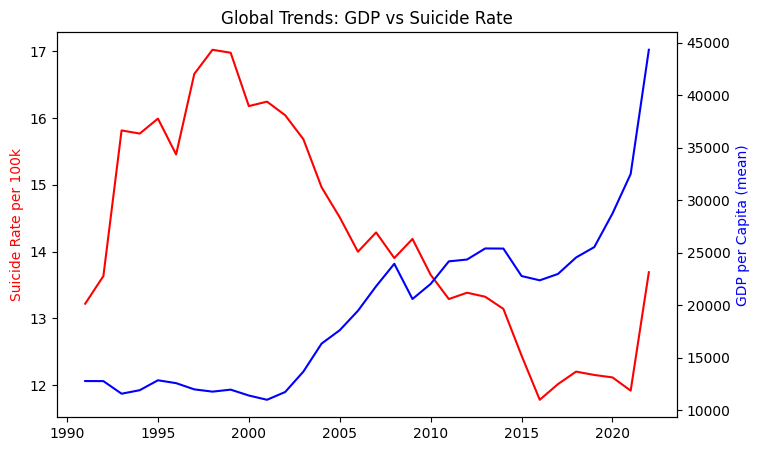

In [ ]:

fig, ax1 = plt.subplots(figsize=(8,5))

# Suicide rate line
ax1.plot(suicide_data.groupby('Year')['DeathRatePer100K'].mean(), color='red', label='Suicide Rate')
ax1.set_ylabel('Suicide Rate per 100k', color='red')

# GDP (scaled) line on secondary axis
ax2 = ax1.twinx()
ax2.plot(suicide_data.groupby('Year')['GDPPerCapita'].mean(), color='blue', label='GDP per Capita')
ax2.set_ylabel('GDP per Capita (mean)', color='blue')

plt.title('Global Trends: GDP vs Suicide Rate')
plt.show()

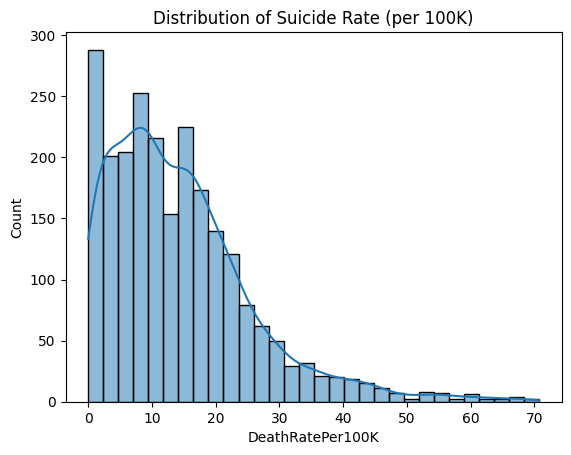

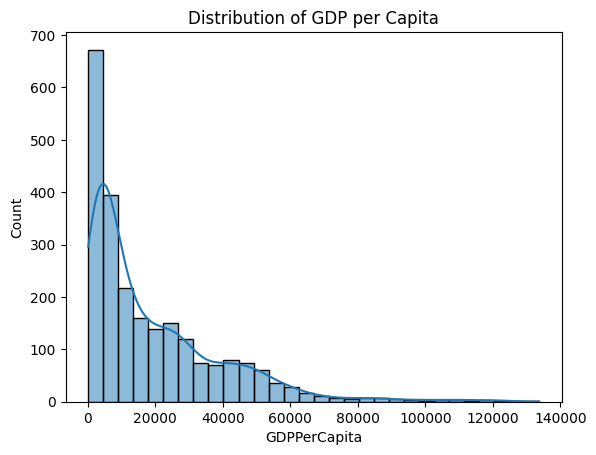

In [ ]:
# Distribution of suicide rate
sns.histplot(df['DeathRatePer100K'], bins=30, kde=True)
plt.title("Distribution of Suicide Rate (per 100K)")
plt.show()

# GDP per capita distribution
sns.histplot(df['GDPPerCapita'], bins=30, kde=True)
plt.title("Distribution of GDP per Capita")
plt.show()



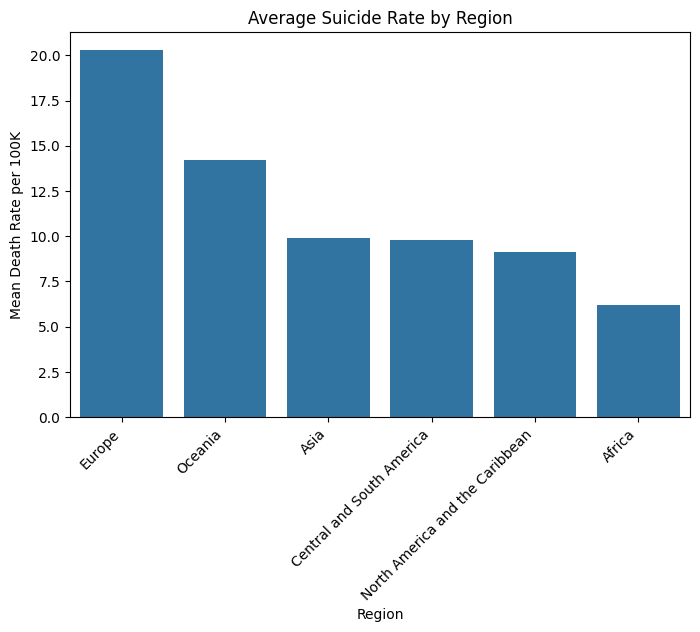

In [ ]:
# Average suicide rate per region
# order regions by mean suicide rate (desc)
order = (df.groupby('RegionName')['DeathRatePer100K']
           .mean()
           .sort_values(ascending=False)
           .index)

plt.figure(figsize=(8,5))
sns.barplot(
    data=df, x='RegionName', y='DeathRatePer100K',
    estimator='mean', errorbar=None, order=order
)
plt.xticks(rotation=45, ha='right')
plt.title("Average Suicide Rate by Region")
plt.ylabel("Mean Death Rate per 100K")
plt.xlabel("Region")
plt.show()



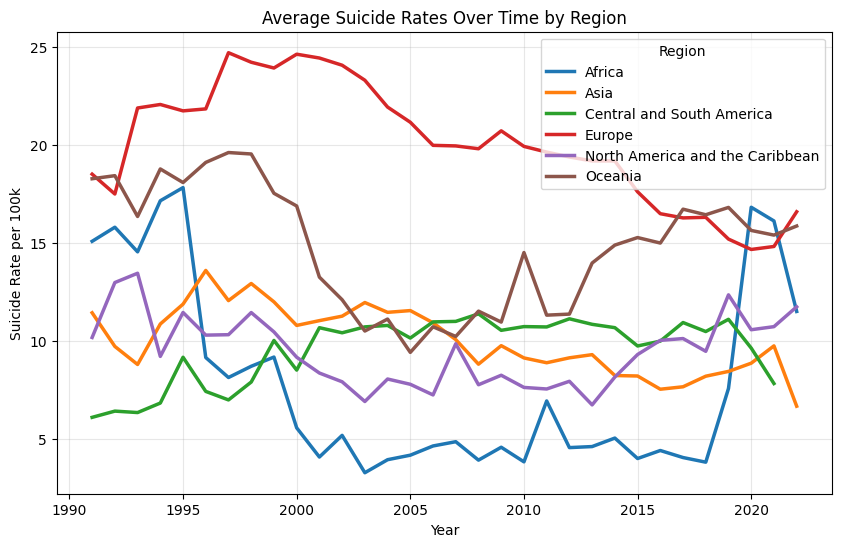

In [ ]:


region_trends = (
    suicide_data
    .groupby(['RegionName', 'Year'], as_index=False)
    .agg({
        'DeathRatePer100K': 'mean',
        'GDPPerCapita': 'mean'
    })
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=region_trends,
    x='Year',
    y='DeathRatePer100K',
    hue='RegionName',
    linewidth=2.5
)

plt.title('Average Suicide Rates Over Time by Region')
plt.xlabel('Year')
plt.ylabel('Suicide Rate per 100k')
plt.legend(title='Region')
plt.grid(True, alpha=0.3)
plt.show()

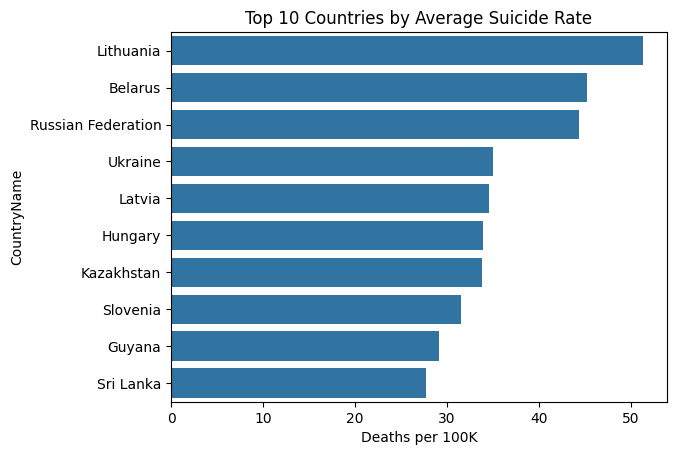

In [ ]:
# Top 10 countries with highest suicide rates (average across years)
top_countries = (df.groupby('CountryName')['DeathRatePer100K']
                   .mean().nlargest(10))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Average Suicide Rate")
plt.xlabel("Deaths per 100K")
plt.show()


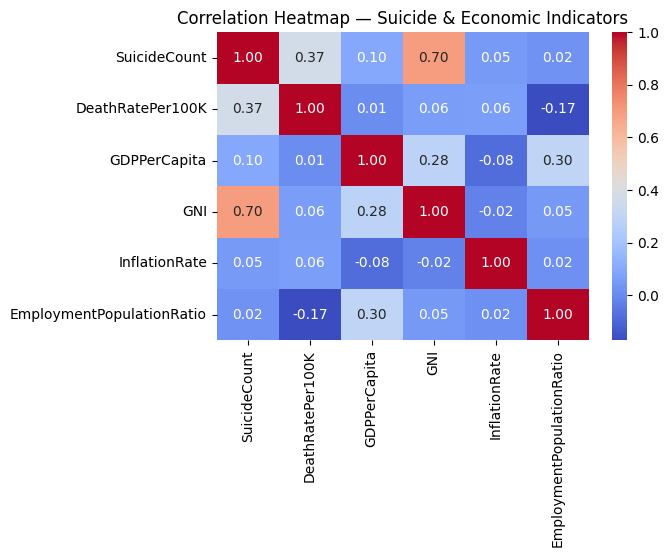

In [ ]:
numeric_cols = ['SuicideCount','DeathRatePer100K','GDPPerCapita','GNI','InflationRate','EmploymentPopulationRatio']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap — Suicide & Economic Indicators")
plt.show()


death rate per 100k -> slight negative correlation, so higher employment reduces suicide rates

GNI and suicide count -> Strong positive — countries with higher gross national income tend to report more suicides overall. This likely reflects population size and reporting accuracy, not necessarily higher suicide rates.

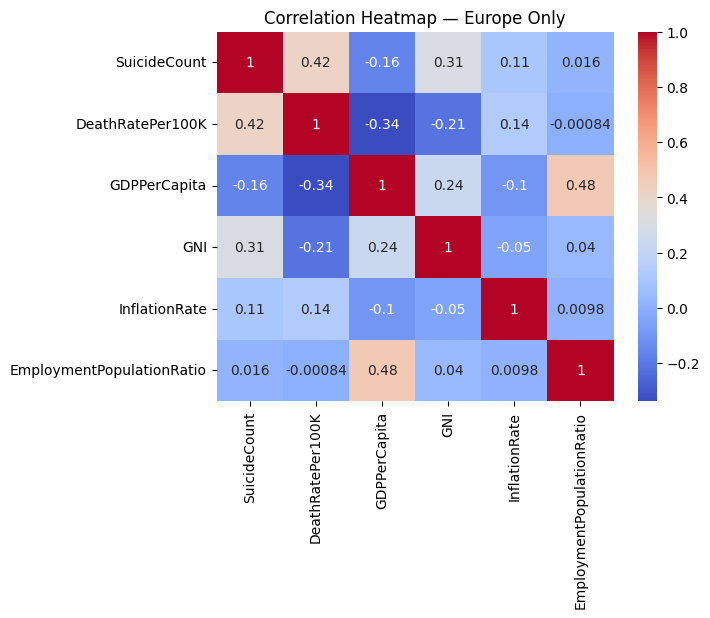

In [ ]:
corr_by_region = df.groupby("RegionName")[numeric_cols].corr().loc["Europe"]
sns.heatmap(corr_by_region, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap — Europe Only")
plt.show()


Highest rate was of europe, analyzing that now

SuicideCount ↔ GNI, 0.31, Mild positive — wealthier nations (in total income) tend to report more suicides, likely due to larger, better-tracked populations, not necessarily higher risk.

SuicideCount ↔ GDPPerCapita, -0.16, richer individuals (on average) don’t necessarily imply more suicides; might even slightly reduce counts.

DeathRatePer100K ↔ GDPPerCapita, higher-income European countries tend to have lower suicide rates per 100K, suggesting better mental health resources and social safety nets.

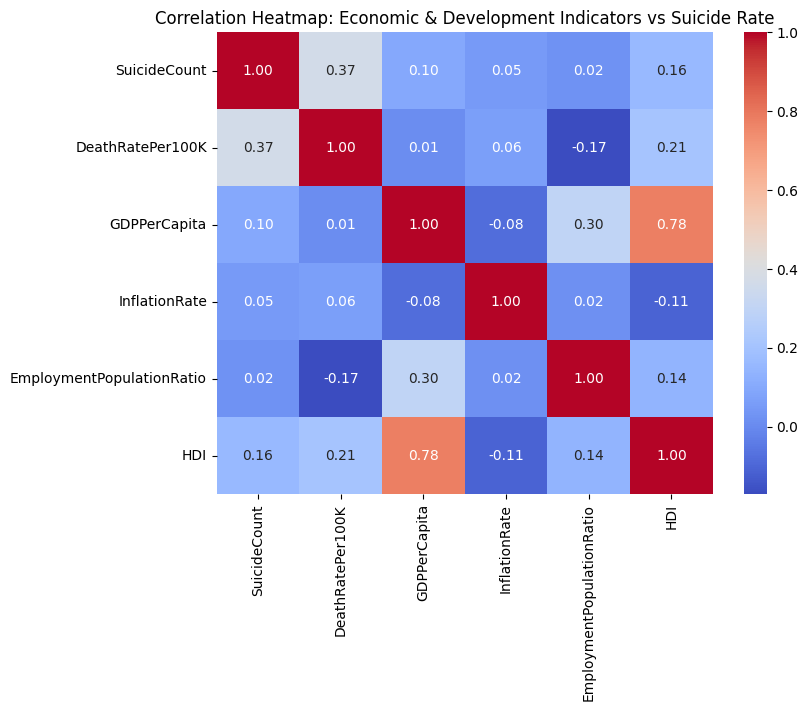

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    merged_all[['SuicideCount','DeathRatePer100K', 'GDPPerCapita', 'InflationRate',
                'EmploymentPopulationRatio', 'HDI']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap: Economic & Development Indicators vs Suicide Rate')
plt.show()

Filtered out 40 outlier rows


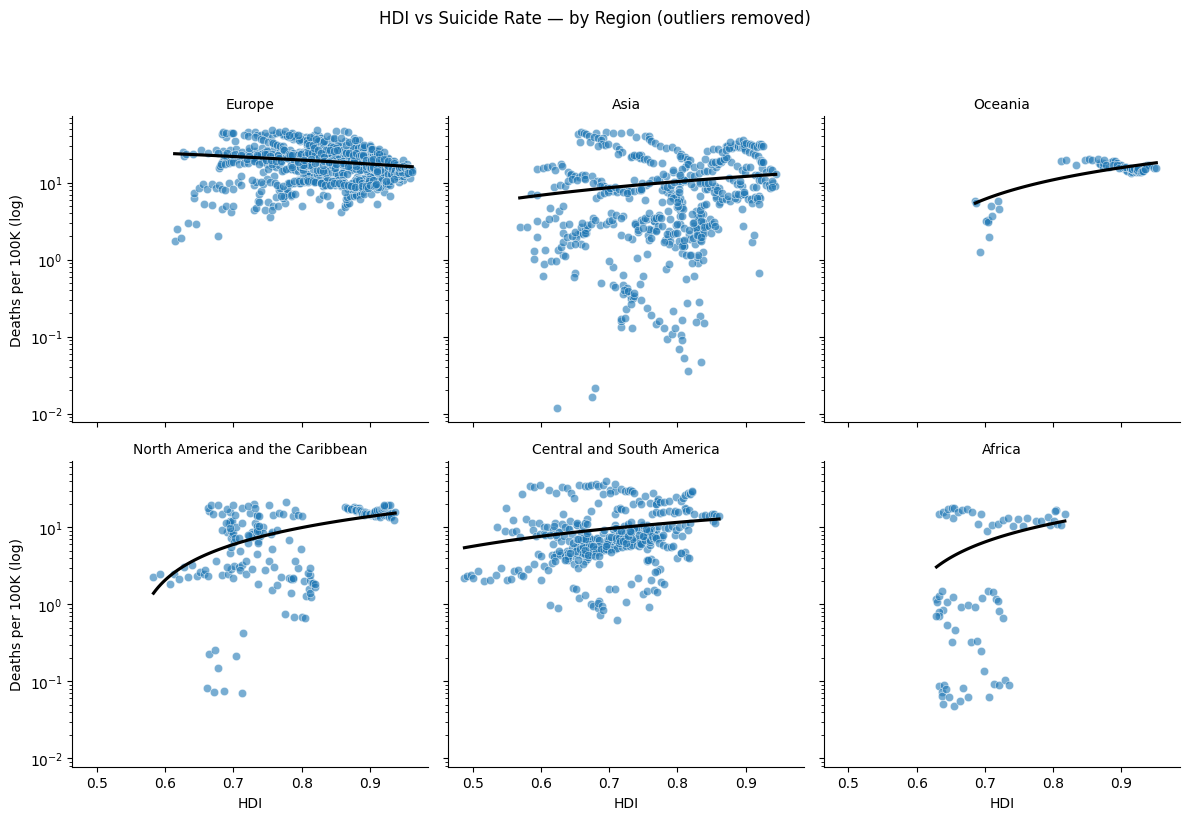

In [ ]:
from scipy import stats
filtered = merged_all[(np.abs(stats.zscore(merged_all['DeathRatePer100K'])) < 3)]


print(f"Filtered out {(len(merged_all) - len(filtered))} outlier rows")

g = sns.FacetGrid(filtered, col="RegionName", col_wrap=3, height=4, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="HDI", y="DeathRatePer100K", alpha=0.6)
g.map_dataframe(sns.regplot, x="HDI", y="DeathRatePer100K", scatter=False, color="black", ci=None)

for ax in g.axes.flat:
    ax.set_xscale("linear")
    ax.set_yscale("log")

g.set_axis_labels("HDI", "Deaths per 100K (log)")
g.set_titles("{col_name}")
g.fig.suptitle("HDI vs Suicide Rate — by Region (outliers removed)", y=1.02)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


Focusing on Europe

/var/folders/hk/jdbbgd7s16sdbbc83nwpvnxw0000gn/T/ipykernel_76083/2277390615.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  curve = eu.groupby('bin', observed=True).apply(


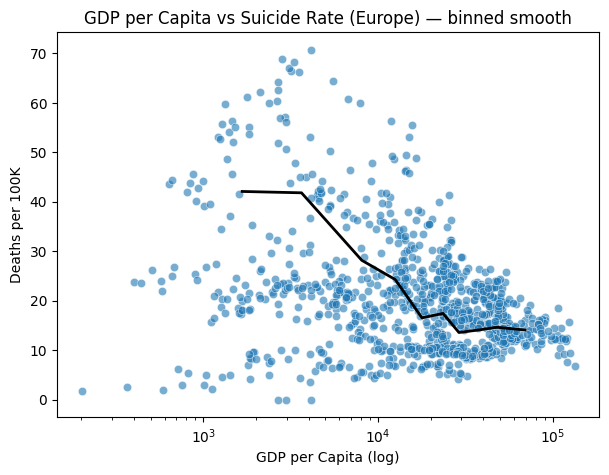

In [ ]:
eu = merged_all.loc[(merged_all.RegionName=="Europe") & (merged_all.GDPPerCapita>0),
                    ['GDPPerCapita','DeathRatePer100K','Population']].dropna().copy()

eu['bin'] = pd.qcut(eu['GDPPerCapita'], q=10, duplicates='drop')

curve = eu.groupby('bin', observed=True).apply(
    lambda g: pd.Series({
        'GDPPerCapita': np.average(g['GDPPerCapita'], weights=g['Population']),
        'DeathRatePer100K': np.average(g['DeathRatePer100K'], weights=g['Population'])
    })
).reset_index(drop=True)

plt.figure(figsize=(7,5))
sns.scatterplot(data=eu, x='GDPPerCapita', y='DeathRatePer100K', alpha=0.6)
plt.plot(curve['GDPPerCapita'], curve['DeathRatePer100K'], color='black', linewidth=2)
plt.xscale('log')
plt.xlabel("GDP per Capita (log)"); plt.ylabel("Deaths per 100K")
plt.title("GDP per Capita vs Suicide Rate (Europe) — binned smooth")
plt.show()


# FINAL ANALYSIS

### Answering the Question: How do suicide rates respond to macroeconomic crises, such as periods of high inflation or sudden GDP contractions? Can we observe lagged effects (eg., suicide rates increasing 1-2 years after an economic downturn)?

In [ ]:
df = merged_all.copy()

# only getting the relevant columns
use_cols = [
    'CountryName', 'RegionName', 'Year',
    'DeathRatePer100K', 'SuicideCount',
    'Population',
    'GDP', 'GDPPerCapita',
    'GNI', 'GNIPerCapita',
    'InflationRate', 'EmploymentPopulationRatio', 'HDI'
]

df = df[use_cols].dropna(subset=[
    'CountryName','Year','DeathRatePer100K','GDPPerCapita','InflationRate'
])

df = df.sort_values(['CountryName','Year']).reset_index(drop=True)
df.head()

,CountryName,RegionName,Year,DeathRatePer100K,SuicideCount,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio,HDI
0,Albania,Europe,1992,1.718396,47,3247039.0,6.521750e+08,200.852220,9.061842e+08,1740.0,226.005421,45.315,0.614
1,Albania,Europe,1993,2.474457,73,3227287.0,1.185315e+09,367.279225,1.024263e+09,2110.0,85.004751,47.798,0.617
2,Albania,Europe,1994,1.927536,52,3207536.0,1.880951e+09,586.416135,1.216681e+09,2300.0,22.565053,50.086,0.624
3,Albania,Europe,1995,2.994703,91,3187784.0,2.392765e+09,750.604449,2.035220e+09,2710.0,7.793219,53.186,0.634
4,Albania,Europe,1996,2.876627,92,3168033.0,3.199641e+09,1009.977111,2.823912e+09,3050.0,12.725478,53.039,0.645


In [ ]:
# GDP growth (%) — based on GDPPerCapita
df['GDPperCapitaGrowthPct'] = df.groupby('CountryName')['GDPPerCapita'].pct_change() * 100

# Inflation year-on-year change
df['InflationChange'] = df.groupby('CountryName')['InflationRate'].diff()

# Suicide rate change (per 100k)
df['SuicideDiff'] = df.groupby('CountryName')['DeathRatePer100K'].diff()


#basically to remove the first null row
df = df.dropna(subset=[
    'GDPperCapitaGrowthPct',
    'InflationChange',
    'SuicideDiff'
])

df[['CountryName','Year','DeathRatePer100K','GDPPerCapita',
    'GDPperCapitaGrowthPct','InflationRate','InflationChange','SuicideDiff']].head(12)


,CountryName,Year,DeathRatePer100K,GDPPerCapita,GDPperCapitaGrowthPct,InflationRate,InflationChange,SuicideDiff
1,Albania,1993,2.474457,367.279225,82.860426,85.004751,-141.000670,0.756061
2,Albania,1994,1.927536,586.416135,59.664935,22.565053,-62.439699,-0.546921
3,Albania,1995,2.994703,750.604449,27.998601,7.793219,-14.771834,1.067166
4,Albania,1996,2.876627,1009.977111,34.555172,12.725478,4.932259,-0.118075
5,Albania,1997,6.269547,717.380048,-28.970663,33.180274,20.454797,3.392920
6,Albania,1998,5.296444,813.789397,13.439090,20.642859,-12.537416,-0.973103
7,Albania,1999,5.051384,1033.242532,26.966822,0.389438,-20.253421,-0.245059
8,Albania,2000,2.049614,1126.683340,9.043454,0.050018,-0.339420,-3.001771
9,Albania,2001,4.543267,1281.659826,13.755106,3.107588,3.057570,2.493654
10,Albania,2002,4.906757,1425.124219,11.193640,7.770526,4.662938,0.363490


Defining Crisis Years

A. GDP Crisis = TRUE if ANY of these hold:
- GDP per capita drops ≥ 2% from previous year
- GDP growth rate goes negative
- Year is one of the known global recession years:
    - 1998 (Asian Financial Crisis)
    - 2008 (Global Financial Crisis)
    - 2020 (COVID-19 global recession)

B. Inflation Crisis = TRUE if ANY of these hold:
- Inflation > 10%
- Inflation increases ≥ 5% from previous year

C. Any Crisis = TRUE if GDP crisis OR inflation crisis

In [ ]:
# Known global recession years
global_recession_years = [1998, 2008, 2020]

# GDP CRISIS
# Condition 1 for a crisis year is if GDP per capita drops ≥ 2%
cond_gdp_drop_2pct = df['GDPperCapitaGrowthPct'] <= -2

# Condition 2 is if there is a  negative GDP growth rate
cond_negative_growth = df['GDPperCapitaGrowthPct'] < 0

# Condition 3 is if its any known global recession year
cond_global_recession_year = df['Year'].isin(global_recession_years)

# Combine GDP crisis conditions
df['GDP_Crisis'] = (
    cond_gdp_drop_2pct |
    cond_negative_growth |
    cond_global_recession_year
)

# INFLATION CRISIS
# Condition 1 is if inflation > 10%
cond_inflation_high_level = df['InflationRate'] > 10

# Condition 2 is if inflation increased ≥ 5% from previous year
cond_inflation_spike = df['InflationChange'] >= 5

# Combine inflation crisis conditions
df['Inflation_Crisis'] = (
    cond_inflation_high_level |
    cond_inflation_spike
)
# ANY CRISIS = GDP crisis OR inflation crisis
df['Any_Crisis'] = df['GDP_Crisis'] | df['Inflation_Crisis']

df[['CountryName','Year','GDPPerCapita','GDPperCapitaGrowthPct','InflationRate',
    'InflationChange','GDP_Crisis','Inflation_Crisis','Any_Crisis']].head(50)


,CountryName,Year,GDPPerCapita,GDPperCapitaGrowthPct,InflationRate,InflationChange,GDP_Crisis,Inflation_Crisis,Any_Crisis
1,Albania,1993,367.279225,82.860426,85.004751,-141.000670,False,True,True
2,Albania,1994,586.416135,59.664935,22.565053,-62.439699,False,True,True
3,Albania,1995,750.604449,27.998601,7.793219,-14.771834,False,False,False
4,Albania,1996,1009.977111,34.555172,12.725478,4.932259,False,True,True
5,Albania,1997,717.380048,-28.970663,33.180274,20.454797,True,True,True
6,Albania,1998,813.789397,13.439090,20.642859,-12.537416,True,True,True
7,Albania,1999,1033.242532,26.966822,0.389438,-20.253421,False,False,False
8,Albania,2000,1126.683340,9.043454,0.050018,-0.339420,False,False,False
9,Albania,2001,1281.659826,13.755106,3.107588,3.057570,False,False,False
10,Albania,2002,1425.124219,11.193640,7.770526,4.662938,False,False,False


Top countries selected: ['United States of America', 'Brazil', 'Russian Federation', 'Japan', 'Mexico']


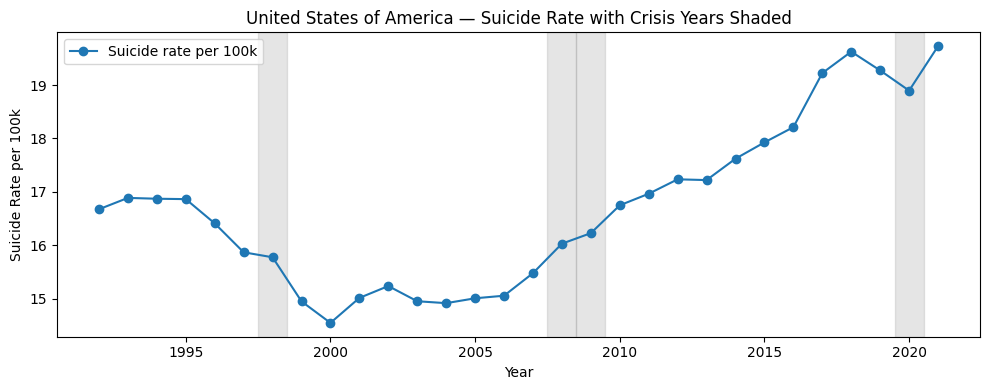

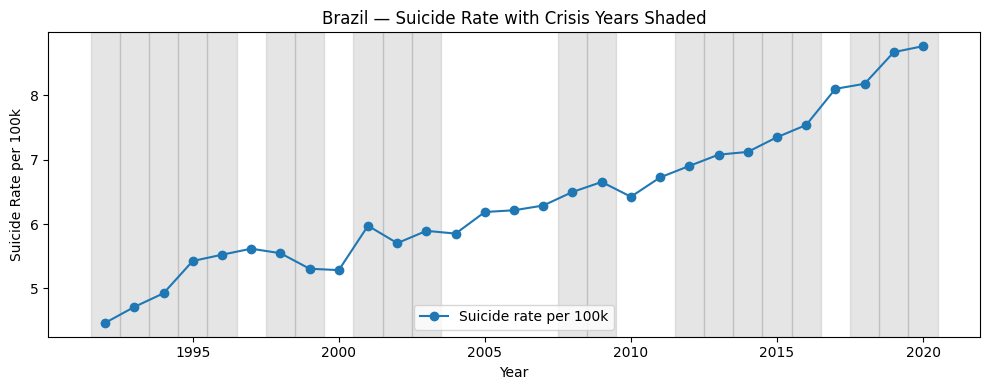

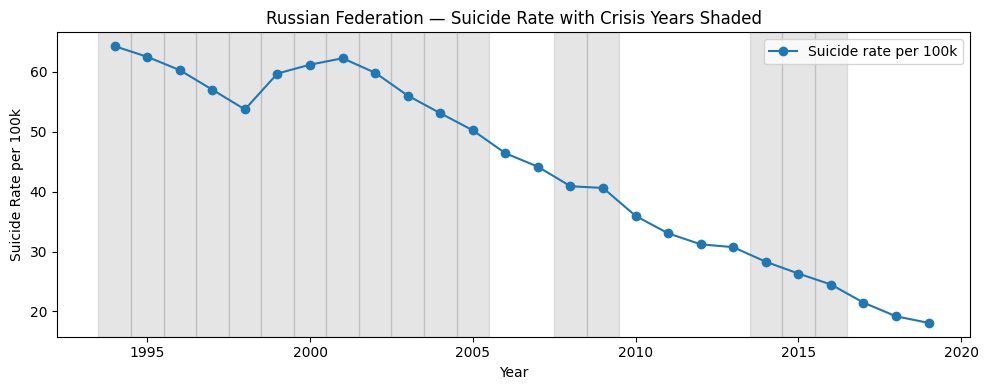

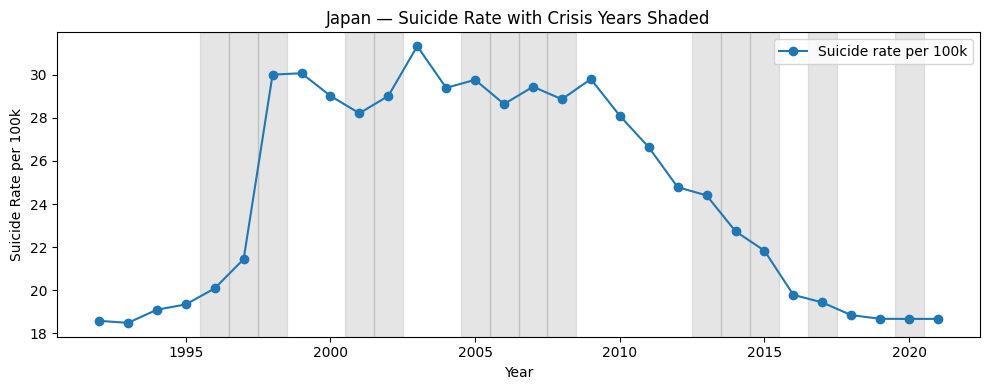

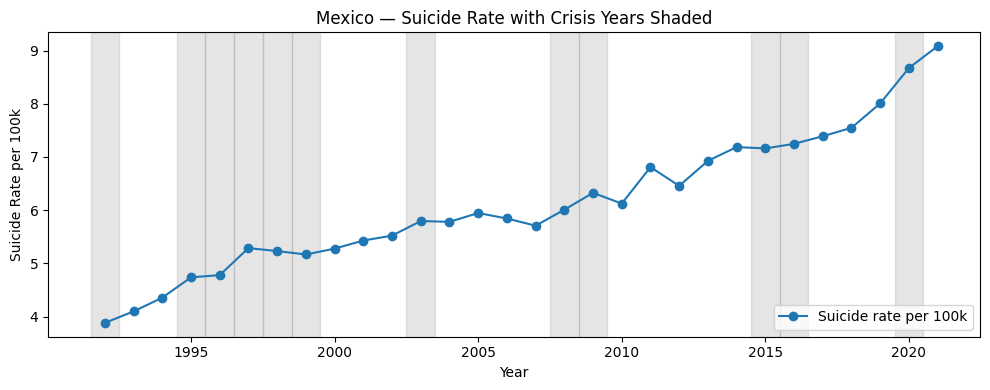

In [ ]:

# Choosing some example countries
# top 3 countries by average population
top_countries = (
    df.groupby('CountryName')['Population']
      .mean()
      .sort_values(ascending=False)
      .head(5)
      .index
      .tolist()
)

print("Top countries selected:", top_countries)

# Plot suicide rate with crisis shading for these countries
for c in top_countries:
    sub = df[df['CountryName'] == c].sort_values('Year')
    if sub.empty:
        continue

    plt.figure(figsize=(10, 4))
    plt.plot(sub['Year'], sub['DeathRatePer100K'], marker='o', label='Suicide rate per 100k')

    # Shade crisis years using the Any_Crisis flag
    for _, row in sub[sub['Any_Crisis']].iterrows():
        plt.axvspan(row['Year'] - 0.5, row['Year'] + 0.5,
                    alpha=0.2, color='gray')

    plt.title(f"{c} — Suicide Rate with Crisis Years Shaded")
    plt.xlabel("Year")
    plt.ylabel("Suicide Rate per 100k")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.stats import ttest_ind

tmp = df.dropna(subset=['SuicideDiff'])

crisis = tmp[tmp['Any_Crisis']]['SuicideDiff']
normal = tmp[~tmp['Any_Crisis']]['SuicideDiff']

print("Mean change during crisis years:", crisis.mean())
print("Mean change during non-crisis years:", normal.mean())

t_stat, p_val = ttest_ind(crisis, normal, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_val)

Mean change during crisis years: -0.014402532707323836
Mean change during non-crisis years: -0.2483914139164001
t-statistic: 2.493778105318344
p-value: 0.012719232423981208


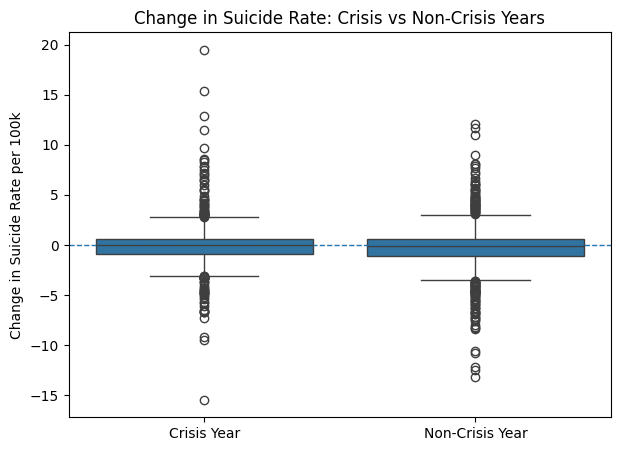

In [ ]:
tmp = tmp.copy()
tmp['CrisisLabel'] = np.where(tmp['Any_Crisis'], 'Crisis Year', 'Non-Crisis Year')

plt.figure(figsize=(7,5))
sns.boxplot(data=tmp, x='CrisisLabel', y='SuicideDiff')
plt.axhline(0, linestyle='--', linewidth=1)
plt.title("Change in Suicide Rate: Crisis vs Non-Crisis Years")
plt.ylabel("Change in Suicide Rate per 100k")
plt.xlabel("")
plt.show()


In [ ]:
df = df.copy()
# Create 1 year and 2 year lag columns for GDP growth and inflation for each country
for var in ['GDPperCapitaGrowthPct', 'InflationRate']:
    df[f'{var}_lag1'] = df.groupby('CountryName')[var].shift(1)
    df[f'{var}_lag2'] = df.groupby('CountryName')[var].shift(2)
# Keep only rows where all needed lagged and current values are there
clean_df = df.dropna(subset=[
    'GDPperCapitaGrowthPct', 'GDPperCapitaGrowthPct_lag1', 'GDPperCapitaGrowthPct_lag2',
    'InflationRate', 'InflationRate_lag1', 'InflationRate_lag2',
    'DeathRatePer100K'
]).copy()

df = clean_df.copy()

df[['CountryName','Year','GDPperCapitaGrowthPct','GDPperCapitaGrowthPct_lag1','GDPperCapitaGrowthPct_lag2',
    'InflationRate','InflationRate_lag1','InflationRate_lag2']].head(10)


,CountryName,Year,GDPperCapitaGrowthPct,GDPperCapitaGrowthPct_lag1,GDPperCapitaGrowthPct_lag2,InflationRate,InflationRate_lag1,InflationRate_lag2
3,Albania,1995,27.998601,59.664935,82.860426,7.793219,22.565053,85.004751
4,Albania,1996,34.555172,27.998601,59.664935,12.725478,7.793219,22.565053
5,Albania,1997,-28.970663,34.555172,27.998601,33.180274,12.725478,7.793219
6,Albania,1998,13.439090,-28.970663,34.555172,20.642859,33.180274,12.725478
7,Albania,1999,26.966822,13.439090,-28.970663,0.389438,20.642859,33.180274
8,Albania,2000,9.043454,26.966822,13.439090,0.050018,0.389438,20.642859
9,Albania,2001,13.755106,9.043454,26.966822,3.107588,0.050018,0.389438
10,Albania,2002,11.193640,13.755106,9.043454,7.770526,3.107588,0.050018
11,Albania,2003,29.540997,11.193640,13.755106,0.484003,7.770526,3.107588
12,Albania,2004,28.571335,29.540997,11.193640,2.280019,0.484003,7.770526


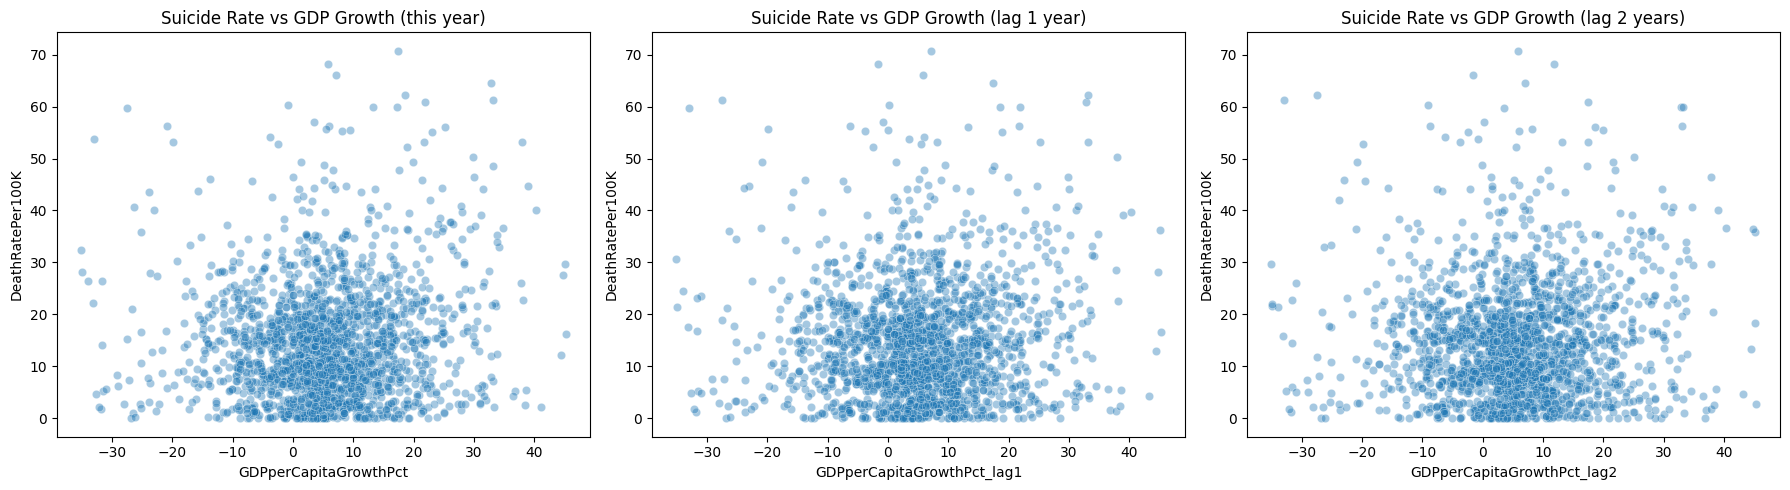

In [ ]:
plot_df = df[
    (df['GDPperCapitaGrowthPct'] > -50) &
    (df['GDPperCapitaGrowthPct'] < 50) &
    (df['GDPperCapitaGrowthPct_lag1'] > -50) &
    (df['GDPperCapitaGrowthPct_lag1'] < 50) &
    (df['GDPperCapitaGrowthPct_lag2'] > -50) &
    (df['GDPperCapitaGrowthPct_lag2'] < 50)
].copy()


fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=plot_df, x='GDPperCapitaGrowthPct', y='DeathRatePer100K', alpha=0.4, ax=axes[0])
axes[0].set_title("Suicide Rate vs GDP Growth (this year)")

sns.scatterplot(data=plot_df, x='GDPperCapitaGrowthPct_lag1', y='DeathRatePer100K', alpha=0.4, ax=axes[1])
axes[1].set_title("Suicide Rate vs GDP Growth (lag 1 year)")

sns.scatterplot(data=plot_df, x='GDPperCapitaGrowthPct_lag2', y='DeathRatePer100K', alpha=0.4, ax=axes[2])
axes[2].set_title("Suicide Rate vs GDP Growth (lag 2 years)")


plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.formula.api as smf

# These are the columns we need for the regression.
# If any of them are missing in a row, we will drop that row.
reg_cols = [
    'DeathRatePer100K',
    'GDPperCapitaGrowthPct', 'GDPperCapitaGrowthPct_lag1', 'GDPperCapitaGrowthPct_lag2',
    'InflationRate', 'InflationRate_lag1', 'InflationRate_lag2'
]
# Keep only rows where there are no nans.
reg_df = df.dropna(subset=reg_cols).copy()

#this is our regression formula, we want to explain suicide rates (DeathRatePer100K)
# using GDP growth (current, 1-year lag, 2-year lag)
# and inflation (current, 1-year lag, 2-year lag).
formula = """
DeathRatePer100K ~ 
GDPperCapitaGrowthPct + GDPperCapitaGrowthPct_lag1 + GDPperCapitaGrowthPct_lag2 +
InflationRate + InflationRate_lag1 + InflationRate_lag2
"""
#Ordinary Least Squares regression.
model = smf.ols(formula, data=reg_df).fit()
print(model.summary())


ModuleNotFoundError: No module named 'statsmodels'

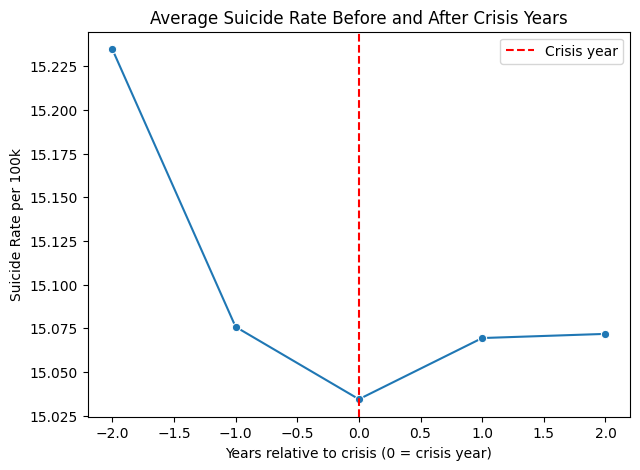

In [ ]:
# select crisis years with enough lag years and previous years
event_rows = []
for country, g in df.groupby('CountryName'):
    g = g.sort_values('Year').reset_index(drop=True)
    crisis_years = g.loc[g['Any_Crisis'], 'Year'].unique()
    if len(crisis_years) == 0:
        continue
    for cy in crisis_years:
        tmp = g.copy()
        tmp['Years_From_Crisis'] = tmp['Year'] - cy
        tmp = tmp[tmp['Years_From_Crisis'].between(-2, 2)]
        tmp['Crisis_Year'] = cy
        event_rows.append(tmp)

if event_rows:
    window = pd.concat(event_rows, ignore_index=True)
else:
    window = pd.DataFrame(columns=list(df.columns) + ['Years_From_Crisis','Crisis_Year'])

# Average across all crisis events
avg_event = window.groupby('Years_From_Crisis')['DeathRatePer100K'].mean().reset_index()

# Plot
plt.figure(figsize=(7,5))
sns.lineplot(data=avg_event, x='Years_From_Crisis', y='DeathRatePer100K', marker='o')
plt.axvline(0, color='red', linestyle='--', label='Crisis year')
plt.title("Average Suicide Rate Before and After Crisis Years")
plt.xlabel("Years relative to crisis (0 = crisis year)")
plt.ylabel("Suicide Rate per 100k")
plt.legend()
plt.show()


## Research Question 2: In times of rising unemployment, do countries with stronger welfare systems, reflected in HDI, show smaller increases in suicides?

In [ ]:
df = merged_all.copy()
df

,RegionCode,RegionName,CountryCode,CountryName,Year,SuicideCount,DeathRatePer100K,StdDeathRate,CauseSpecificDeathPercentage,Population,GDP,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio,HDI
0,EU,Europe,ALB,Albania,1992,47,1.718396,1.898114,0.290227,3247039.0,6.521750e+08,200.852220,9.061842e+08,1740.0,226.005421,45.315,0.614
1,EU,Europe,ALB,Albania,1993,73,2.474457,2.748085,0.443489,3227287.0,1.185315e+09,367.279225,1.024263e+09,2110.0,85.004751,47.798,0.617
2,EU,Europe,ALB,Albania,1994,52,1.927536,2.191109,0.368643,3207536.0,1.880951e+09,586.416135,1.216681e+09,2300.0,22.565053,50.086,0.624
3,EU,Europe,ALB,Albania,1995,91,2.994703,3.081853,0.571692,3187784.0,2.392765e+09,750.604449,2.035220e+09,2710.0,7.793219,53.186,0.634
4,EU,Europe,ALB,Albania,1996,92,2.876627,3.137068,0.549586,3168033.0,3.199641e+09,1009.977111,2.823912e+09,3050.0,12.725478,53.039,0.645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2350,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2012,731,3.542191,3.823889,0.584494,29470426.0,3.810000e+11,12937.927600,3.730000e+11,16960.0,21.068996,58.945,0.767
2351,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2013,618,2.885841,3.090208,0.482841,29838021.0,3.710000e+11,12433.980790,3.570000e+11,16960.0,40.639428,57.909,0.774
2352,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2014,569,2.727958,2.975724,0.426417,30193258.0,4.820000e+11,15975.729380,3.930000e+11,16960.0,62.168650,57.925,0.770
2353,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2015,575,2.653898,2.886563,0.403560,30529716.0,4.820000e+11,15975.729380,3.930000e+11,16960.0,121.738085,57.914,0.767


In [ ]:
#we sort the data by country and year
df = df.sort_values(['CountryName', 'Year']).reset_index(drop=True)

# Calculate how much the employment to population ratio changed from last year.
# For each country, we subtract last years from this years
df['EmpRatioChange'] = df.groupby('CountryName')['EmploymentPopulationRatio'].diff()

# Suicide rate change (per 100k) from last year
df['SuicideDiff'] = df.groupby('CountryName')['DeathRatePer100K'].diff()

#Remove any rows where either of the above differences arent there
df = df.dropna(subset=['EmpRatioChange', 'SuicideDiff']).reset_index(drop=True)

df[['CountryName','Year','EmploymentPopulationRatio','EmpRatioChange',
    'DeathRatePer100K','SuicideDiff']].head(10)


,CountryName,Year,EmploymentPopulationRatio,EmpRatioChange,DeathRatePer100K,SuicideDiff
0,Albania,1993,47.798,2.483,2.474457,0.756061
1,Albania,1994,50.086,2.288,1.927536,-0.546921
2,Albania,1995,53.186,3.100,2.994703,1.067166
3,Albania,1996,53.039,-0.147,2.876627,-0.118075
4,Albania,1997,51.873,-1.166,6.269547,3.392920
5,Albania,1998,49.373,-2.500,5.296444,-0.973103
6,Albania,1999,48.201,-1.172,5.051384,-0.245059
7,Albania,2000,48.925,0.724,2.049614,-3.001771
8,Albania,2001,48.760,-0.165,4.543267,2.493654
9,Albania,2002,48.943,0.183,4.906757,0.363490


In [ ]:
# Flag employment shock years
df['EmpShock'] = df['EmpRatioChange'] <= -1  # drop of at least 1 percentage point

df[['CountryName','Year','EmpRatioChange','EmpShock']].head(15)


,CountryName,Year,EmpRatioChange,EmpShock
0,Albania,1993,2.483,False
1,Albania,1994,2.288,False
2,Albania,1995,3.100,False
3,Albania,1996,-0.147,False
4,Albania,1997,-1.166,True
5,Albania,1998,-2.500,True
6,Albania,1999,-1.172,True
7,Albania,2000,0.724,False
8,Albania,2001,-0.165,False
9,Albania,2002,0.183,False


In [ ]:
# Average HDI per country
hdi_country = (
    df.groupby('CountryName')['HDI']
      .mean()
      .reset_index()
      .rename(columns={'HDI': 'HDI_mean'})
)

# get median HDI in all the countries
hdi_median = hdi_country['HDI_mean'].median()
print("HDI median:", hdi_median)

# Label high vs low HDI countries to use later
hdi_country['HDI_Group'] = np.where(hdi_country['HDI_mean'] >= hdi_median,
                                    'High HDI', 'Low HDI')

hdi_country.head(10)


HDI median: 0.774673076923077


,CountryName,HDI_mean,HDI_Group
0,Albania,0.684667,Low HDI
1,Armenia,0.719280,Low HDI
2,Australia,0.912345,High HDI
3,Austria,0.886933,High HDI
4,Azerbaijan,0.627727,Low HDI
5,Bahamas,0.804762,High HDI
6,Bahrain,0.806235,High HDI
7,Barbados,0.767167,Low HDI
8,Belarus,0.747059,Low HDI
9,Belgium,0.898931,High HDI


In [ ]:
#aadding the group into main df
df = df.merge(hdi_country[['CountryName','HDI_Group']],
              on='CountryName', how='left')

df[['CountryName','Year','HDI','HDI_Group']].head(10)


,CountryName,Year,HDI,HDI_Group
0,Albania,1993,0.617,Low HDI
1,Albania,1994,0.624,Low HDI
2,Albania,1995,0.634,Low HDI
3,Albania,1996,0.645,Low HDI
4,Albania,1997,0.642,Low HDI
5,Albania,1998,0.657,Low HDI
6,Albania,1999,0.669,Low HDI
7,Albania,2000,0.677,Low HDI
8,Albania,2001,0.684,Low HDI
9,Albania,2002,0.689,Low HDI


In [ ]:
df

,RegionCode,RegionName,CountryCode,CountryName,Year,SuicideCount,DeathRatePer100K,StdDeathRate,CauseSpecificDeathPercentage,Population,...,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio,HDI,EmpRatioChange,SuicideDiff,EmpShock,HDI_Group
0,EU,Europe,ALB,Albania,1993,73,2.474457,2.748085,0.443489,3227287.0,...,367.279225,1.024263e+09,2110.0,85.004751,47.798,0.617,2.483,0.756061,False,Low HDI
1,EU,Europe,ALB,Albania,1994,52,1.927536,2.191109,0.368643,3207536.0,...,586.416135,1.216681e+09,2300.0,22.565053,50.086,0.624,2.288,-0.546921,False,Low HDI
2,EU,Europe,ALB,Albania,1995,91,2.994703,3.081853,0.571692,3187784.0,...,750.604449,2.035220e+09,2710.0,7.793219,53.186,0.634,3.100,1.067166,False,Low HDI
3,EU,Europe,ALB,Albania,1996,92,2.876627,3.137068,0.549586,3168033.0,...,1009.977111,2.823912e+09,3050.0,12.725478,53.039,0.645,-0.147,-0.118075,False,Low HDI
4,EU,Europe,ALB,Albania,1997,176,6.269547,6.679524,1.127986,3148281.0,...,717.380048,2.532886e+09,2780.0,33.180274,51.873,0.642,-1.166,3.392920,True,Low HDI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2012,731,3.542191,3.823889,0.584494,29470426.0,...,12937.927600,3.730000e+11,16960.0,21.068996,58.945,0.767,-0.295,-0.356263,False,Low HDI
2250,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2013,618,2.885841,3.090208,0.482841,29838021.0,...,12433.980790,3.570000e+11,16960.0,40.639428,57.909,0.774,-1.036,-0.656350,True,Low HDI
2251,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2014,569,2.727958,2.975724,0.426417,30193258.0,...,15975.729380,3.930000e+11,16960.0,62.168650,57.925,0.770,0.016,-0.157883,False,Low HDI
2252,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2015,575,2.653898,2.886563,0.403560,30529716.0,...,15975.729380,3.930000e+11,16960.0,121.738085,57.914,0.767,-0.011,-0.074060,False,Low HDI


In [ ]:
#We drop rows with missing values because they cant be used later to dget the relationship
analysis_df = df.dropna(subset=['SuicideDiff', 'EmpRatioChange']).copy()
analysis_df


,RegionCode,RegionName,CountryCode,CountryName,Year,SuicideCount,DeathRatePer100K,StdDeathRate,CauseSpecificDeathPercentage,Population,...,GDPPerCapita,GNI,GNIPerCapita,InflationRate,EmploymentPopulationRatio,HDI,EmpRatioChange,SuicideDiff,EmpShock,HDI_Group
0,EU,Europe,ALB,Albania,1993,73,2.474457,2.748085,0.443489,3227287.0,...,367.279225,1.024263e+09,2110.0,85.004751,47.798,0.617,2.483,0.756061,False,Low HDI
1,EU,Europe,ALB,Albania,1994,52,1.927536,2.191109,0.368643,3207536.0,...,586.416135,1.216681e+09,2300.0,22.565053,50.086,0.624,2.288,-0.546921,False,Low HDI
2,EU,Europe,ALB,Albania,1995,91,2.994703,3.081853,0.571692,3187784.0,...,750.604449,2.035220e+09,2710.0,7.793219,53.186,0.634,3.100,1.067166,False,Low HDI
3,EU,Europe,ALB,Albania,1996,92,2.876627,3.137068,0.549586,3168033.0,...,1009.977111,2.823912e+09,3050.0,12.725478,53.039,0.645,-0.147,-0.118075,False,Low HDI
4,EU,Europe,ALB,Albania,1997,176,6.269547,6.679524,1.127986,3148281.0,...,717.380048,2.532886e+09,2780.0,33.180274,51.873,0.642,-1.166,3.392920,True,Low HDI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2012,731,3.542191,3.823889,0.584494,29470426.0,...,12937.927600,3.730000e+11,16960.0,21.068996,58.945,0.767,-0.295,-0.356263,False,Low HDI
2250,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2013,618,2.885841,3.090208,0.482841,29838021.0,...,12433.980790,3.570000e+11,16960.0,40.639428,57.909,0.774,-1.036,-0.656350,True,Low HDI
2251,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2014,569,2.727958,2.975724,0.426417,30193258.0,...,15975.729380,3.930000e+11,16960.0,62.168650,57.925,0.770,0.016,-0.157883,False,Low HDI
2252,CSA,Central and South America,VEN,Venezuela (Bolivarian Republic of),2015,575,2.653898,2.886563,0.403560,30529716.0,...,15975.729380,3.930000e+11,16960.0,121.738085,57.914,0.767,-0.011,-0.074060,False,Low HDI


In [ ]:
summary = (
    analysis_df[analysis_df['EmpShock']]
    .groupby('HDI_Group')['SuicideDiff']
    .agg(['mean','median','count'])
    .reset_index()
)

summary


NameError: name 'analysis_df' is not defined

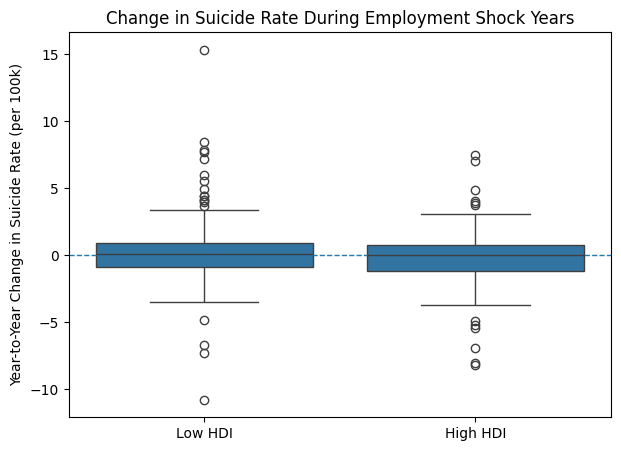

In [ ]:
shock_df = analysis_df[analysis_df['EmpShock']].copy()

plt.figure(figsize=(7,5))
sns.boxplot(data=shock_df, x='HDI_Group', y='SuicideDiff')
plt.axhline(0, linestyle='--', linewidth=1)
plt.title("Change in Suicide Rate During Employment Shock Years")
plt.xlabel("")
plt.ylabel("Year-to-Year Change in Suicide Rate (per 100k)")
plt.show()


In [ ]:
from scipy.stats import ttest_ind
# split the data in two groups of high and low HDI in the years of employment shock.
#we take the suicicde diff from both groups
high = shock_df[shock_df['HDI_Group']=='High HDI']['SuicideDiff']
low  = shock_df[shock_df['HDI_Group']=='Low HDI']['SuicideDiff']

print("High HDI mean:", high.mean())
print("Low HDI mean :", low.mean())
# then we run a welchs t test which compares the mean of both the groups and 
# tells us if higher HDI and lower HDI  countries have a different change in suicicde rates
t_stat, p_val = ttest_ind(high, low, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_val)


NameError: name 'shock_df' is not defined

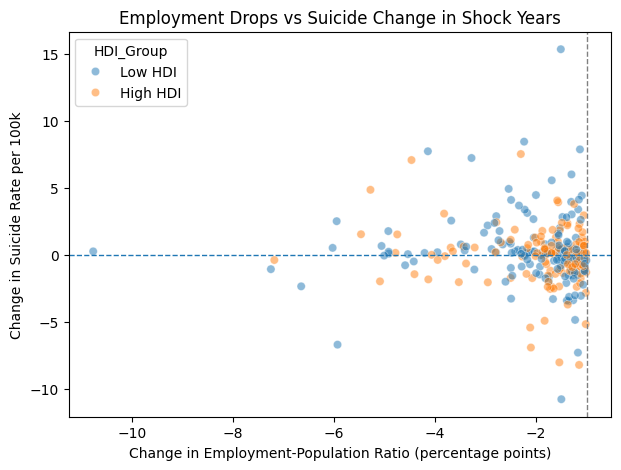

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=analysis_df[analysis_df['EmpShock']], 
    x='EmpRatioChange', 
    y='SuicideDiff',
    hue='HDI_Group',
    alpha=0.5
)
plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(-1, linestyle='--', linewidth=1, color='gray')  # shock threshold
plt.title("Employment Drops vs Suicide Change in Shock Years")
plt.xlabel("Change in Employment-Population Ratio (percentage points)")
plt.ylabel("Change in Suicide Rate per 100k")
plt.show()


In [ ]:
import statsmodels.formula.api as smf

reg = smf.ols(
    "SuicideDiff ~ EmpShock * C(HDI_Group)",
    data=analysis_df
).fit()

print(reg.summary())


                            OLS Regression Results                            
Dep. Variable:            SuicideDiff   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.878
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0348
Time:                        15:51:08   Log-Likelihood:                -4964.8
No. Observations:                2254   AIC:                             9938.
Df Residuals:                    2250   BIC:                             9960.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------